In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
# 1. 加载数据
df = pd.read_csv('/kaggle/input/datasets/darwish1337/ecommerce/ecommerce_dataset.csv')
df.head()

/kaggle/input/datasets/darwish1337/ecommerce/ecommerce_dataset.csv


,product_id,external_id,title,brand,category,subcategory,url,source,price_current,price_original,...,discount_pct,has_discount,rating_score,reviews_count,availability,description,images_count,first_image,tags,scraped_at
0,9efc81ac-b34e-487a-b7a1-6fe9c9d7920b,9749998221059,Huawei Tablet Pro,Huawei,Electronics,NaN,https://www.amazon.com/product/huawei-tablet-p...,amazon,1487.49,NaN,...,NaN,False,4.8,177,in_stock,Crafted with attention to detail and backed by...,1,https://cdn.amazon.example/img/9749998221059.jpg,amazon|electronics,2026-03-21T05:42:24.094706
1,6c26ff34-72d3-45d8-aa01-71e58253e3c6,8979986990555,Adidas Portable Hoodie Plus,Adidas,Fashion,NaN,https://www.amazon.com/product/adidas-portable...,amazon,1125.26,1575.36,...,28.6,True,3.7,665,out_of_stock,A versatile product suitable for a wide range ...,1,https://cdn.amazon.example/img/8979986990555.jpg,amazon|fashion,2026-03-27T11:23:36.862451
2,b271d64f-790b-4561-af51-5ff5d7b0a132,9473792172229,Calvin Klein Sneakers Pro,Calvin,Fashion,NaN,https://www.amazon.com/product/calvin-klein-sn...,amazon,1357.13,NaN,...,NaN,False,3.9,379,out_of_stock,Thoughtfully designed to deliver value without...,1,https://cdn.amazon.example/img/9473792172229.jpg,amazon|fashion,2026-03-24T17:44:49.598673
3,f8beb32f-30b3-4128-b813-820780d2a67c,390919824546,Nestle Lightweight Dried Fruits Pro,Nestle,Food,NaN,https://www.amazon.com/product/nestle-lightwei...,amazon,1553.58,1724.47,...,9.9,True,4.1,4,limited,A trusted choice for professionals and enthusi...,1,https://cdn.amazon.example/img/0390919824546.jpg,amazon|food,2026-03-16T03:50:09.844085
4,bbbb408c-5460-457c-b4ca-55f0af33ee29,3016548993474,Braun Portable Vacuum Cleaner 2024,Braun,Home,NaN,https://www.amazon.com/product/braun-portable-...,amazon,509.81,NaN,...,NaN,False,4.5,88,in_stock,Combining modern aesthetics with functional en...,1,https://cdn.amazon.example/img/3016548993474.jpg,amazon|home,2026-03-14T18:13:11.642972


In [2]:
# 2. 货币统一化 (假设当前汇率转换为 USD)
exchange_rates = {
    'USD': 1.0, 
    'AED': 0.27,  # 阿联酋迪拉姆
    'EGP': 0.021, # 埃及镑
    'GBP': 1.26   # 英镑
}
# 映射汇率并计算统一价格
df['exchange_rate'] = df['currency'].map(exchange_rates)
df['price_current_usd'] = df['price_current'] * df['exchange_rate']
df['price_original_usd'] = df['price_original'] * df['exchange_rate']

# 3. 折扣逻辑对齐
# 如果没有打折，原价应该等于现价，折扣率为 0
df['price_original_usd'] = df['price_original_usd'].fillna(df['price_current_usd'])
df['discount_pct'] = df['discount_pct'].fillna(0.0)
df['has_discount'] = df['discount_pct'] > 0

# 4. 库存状态有序编码 (Ordinal Encoding)
availability_map = {'out_of_stock': 0, 'limited': 1, 'in_stock': 2}
df['availability_score'] = df['availability'].map(availability_map)

print("数据清洗完成！当前数据维度:", df.shape)

数据清洗完成！当前数据维度: (1000, 25)


In [3]:
print(df.columns.tolist())

['product_id', 'external_id', 'title', 'brand', 'category', 'subcategory', 'url', 'source', 'price_current', 'price_original', 'currency', 'discount_pct', 'has_discount', 'rating_score', 'reviews_count', 'availability', 'description', 'images_count', 'first_image', 'tags', 'scraped_at', 'exchange_rate', 'price_current_usd', 'price_original_usd', 'availability_score']


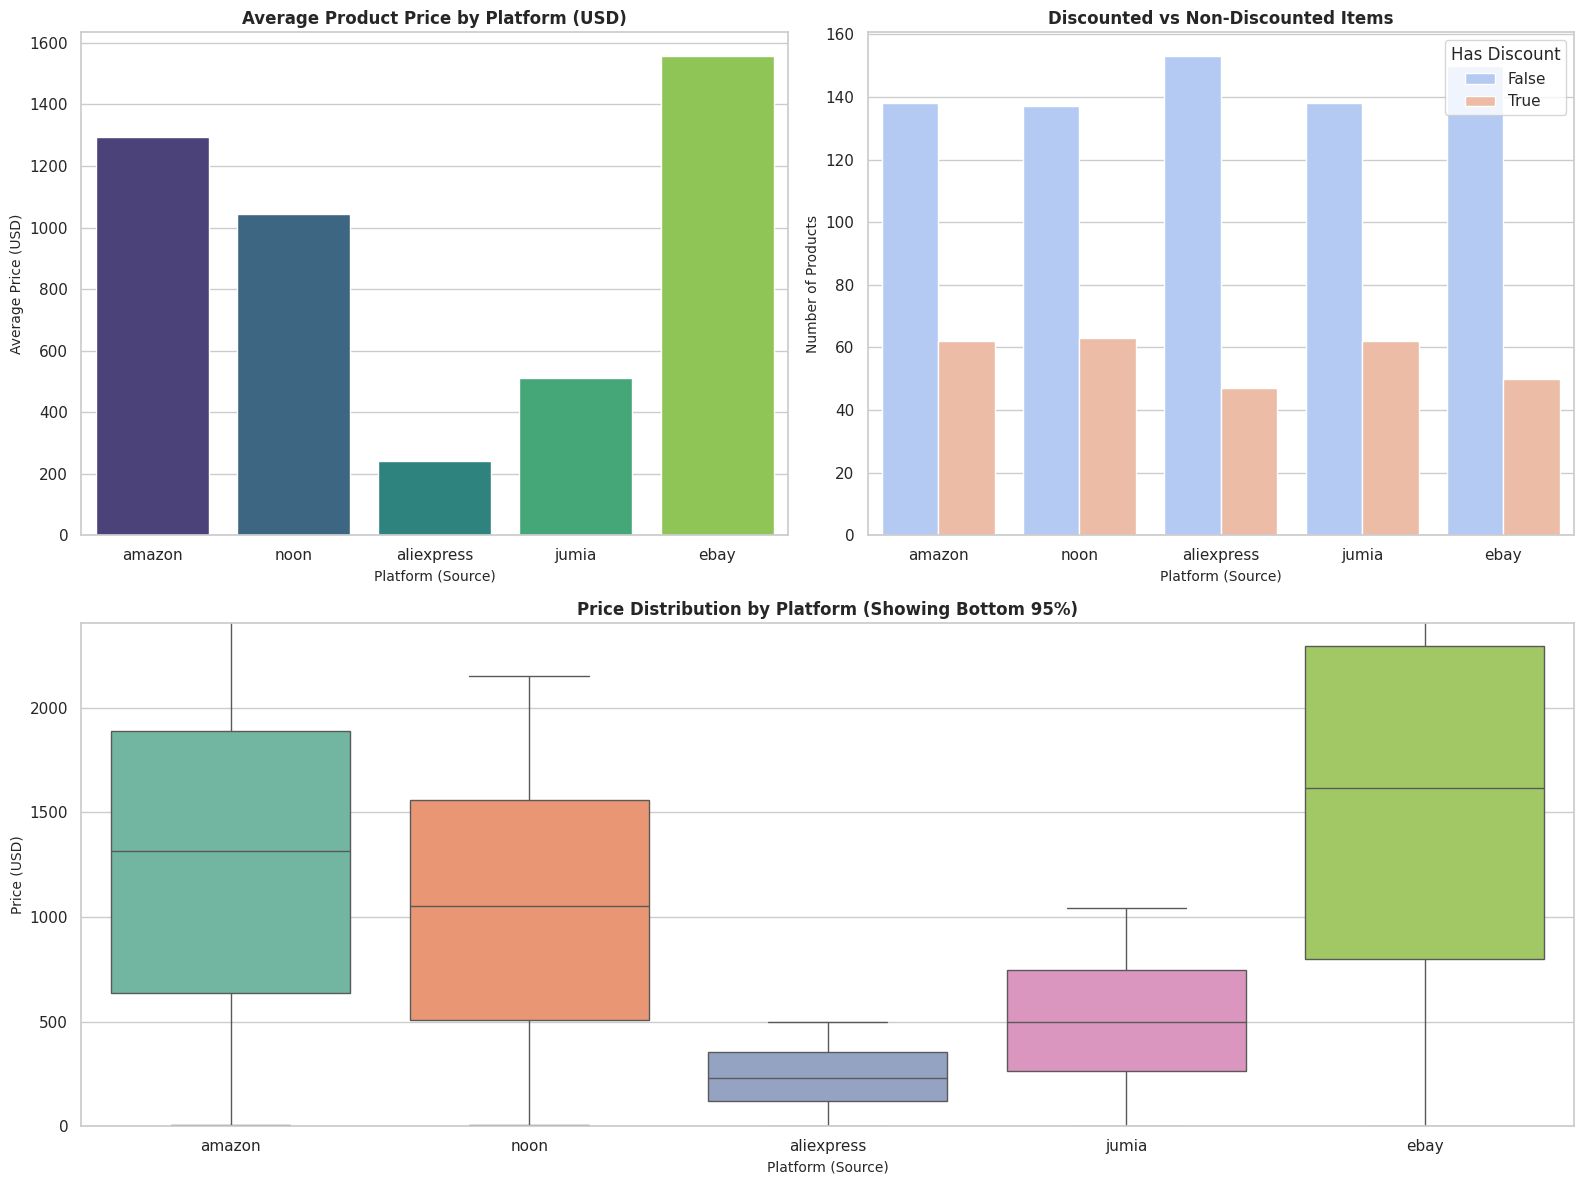

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置图表风格
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12)) 

# 1. 各平台商品均价对比图 (Barplot) - 已修复警告
plt.subplot(2, 2, 1) 
sns.barplot(data=df, x='source', y='price_current_usd', errorbar=None, palette='viridis', hue='source', legend=False)
plt.title('Average Product Price by Platform (USD)', fontsize=12, fontweight='bold')
plt.xlabel('Platform (Source)', fontsize=10)
plt.ylabel('Average Price (USD)', fontsize=10)

# 2. 促销策略分析：谁最喜欢打折？(Countplot) - 这里原本就有 hue，不需要改
plt.subplot(2, 2, 2) 
sns.countplot(data=df, x='source', hue='has_discount', palette='coolwarm')
plt.title('Discounted vs Non-Discounted Items', fontsize=12, fontweight='bold')
plt.xlabel('Platform (Source)', fontsize=10)
plt.ylabel('Number of Products', fontsize=10)
plt.legend(title='Has Discount')

# 3. 各平台价格分布与高端商品洞察 (Boxplot) - 已修复警告
plt.subplot(2, 1, 2) 
sns.boxplot(data=df, x='source', y='price_current_usd', palette='Set2', hue='source', legend=False)

price_95th = df['price_current_usd'].quantile(0.95)
plt.ylim(0, price_95th)
plt.title('Price Distribution by Platform (Showing Bottom 95%)', fontsize=12, fontweight='bold')
plt.xlabel('Platform (Source)', fontsize=10)
plt.ylabel('Price (USD)', fontsize=10)

plt.tight_layout() 
plt.show()

🚀 正在准备数据，进入机器学习阶段...
✅ 模型训练完成！
📊 预测平均误差 (MAE): $483.92 (即模型估算的价格，平均比真实售价相差 483.92 美元)
🎯 模型解释力 (R² Score): 0.24 (满分 1.0，分数越高越好)


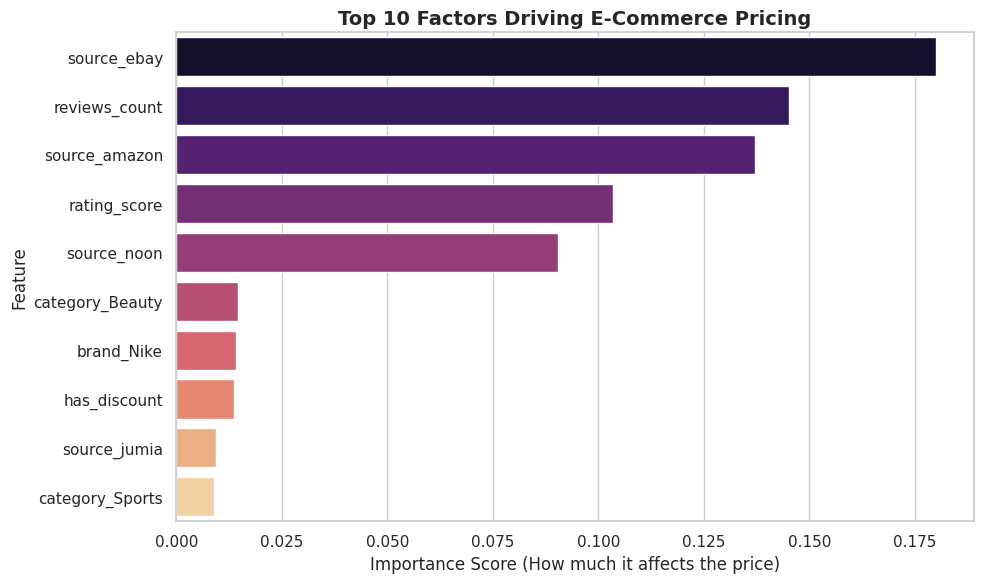

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 第三步：进阶建模 - 价格预测器与特征重要性
# ==========================================

print("🚀 正在准备数据，进入机器学习阶段...")

# 1. 特征选择 (Feature Selection)
# 我们挑出认为可能影响价格的因素（X）和我们要预测的价格（y）
features = ['source', 'category', 'brand', 'rating_score', 'reviews_count', 'has_discount']
target = 'price_current_usd'

# 剔除这些关键列中缺失数据的行，防止模型报错
ml_df = df[features + [target]].dropna()

# 2. 特征工程 (Feature Engineering)
# 机器学习模型是“文盲”，它只认得数字。我们要把文本（如'Amazon', 'Apple'）转成数字（独热编码）
X = pd.get_dummies(ml_df[features], columns=['source', 'category', 'brand'], drop_first=True)
y = ml_df[target]

# 3. 划分考场 (Train-Test Split)
# 拿 80% 的数据给模型学习，留 20% 的数据当期末考试，测试它预测得准不准
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 训练模型 (Model Training)
# 我们雇佣 100 棵“决策树”（随机森林）来集体投票预测价格
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 5. 模型考试与评分 (Model Evaluation)
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"✅ 模型训练完成！")
print(f"📊 预测平均误差 (MAE): ${mae:.2f} (即模型估算的价格，平均比真实售价相差 {mae:.2f} 美元)")
print(f"🎯 模型解释力 (R² Score): {r2:.2f} (满分 1.0，分数越高越好)")

# 6. 终极商业洞察：到底什么决定了价格？(Feature Importance)
importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# 取出影响力排名前 10 的因素
top_10_features = importance_df.sort_values(by='Importance', ascending=False).head(10)

# 画出特征重要性图表
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='magma', hue='Feature', legend=False)
plt.title('Top 10 Factors Driving E-Commerce Pricing', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (How much it affects the price)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()